# 01 — Contract-aware data exploration

This notebook reproduces the input-contract checks directly before profiling the deployment history. The date is treated as chronology, identifiers are correlation keys, and post-deployment columns are explicitly marked as leakage.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = ROOT / "data" / "deployment_events.csv"
if not DATA_PATH.is_file():
    raise FileNotFoundError(f"Place deployment_events.csv at {DATA_PATH}")

sns.set_theme(style="whitegrid")
ID_COLUMNS = ["deployment_id", "device_id", "site_id", "firmware_fingerprint"]
LEAKAGE_COLUMNS = ["time_to_failure_hours", "rollback_required"]
CATEGORICAL_COLUMNS = ["vendor_name", "device_type", "hardware_series", "fleet_tier", "site_criticality", "deployment_type"]
NUMERIC_COLUMNS = [
    "version_jump_magnitude", "kernel_touched", "bootloader_touched",
    "protocol_mismatch_flag", "maintenance_window", "network_stress_score",
    "error_rate_predeploy", "uptime_days", "past_failure_count",
    "firmware_release_age_days", "cve_count", "max_cvss_score",
    "cross_vendor_dependency_count", "dependent_device_count",
]
DATE_COLUMN = "deployment_date"
OUTCOME_COLUMN = "deployment_outcome"
ALLOWED_OUTCOMES = {"SUCCESS", "DEGRADED", "ROLLBACK", "FAILED"}
VERSION_COLUMNS = ["current_firmware", "target_firmware"]
EXPECTED_COLUMNS = ID_COLUMNS + CATEGORICAL_COLUMNS + VERSION_COLUMNS + NUMERIC_COLUMNS + [DATE_COLUMN, OUTCOME_COLUMN] + LEAKAGE_COLUMNS

raw = pd.read_csv(DATA_PATH)
missing_columns = sorted(set(EXPECTED_COLUMNS) - set(raw.columns))
assert not missing_columns, f"Missing required columns: {missing_columns}"
invalid_outcomes = sorted(set(raw[OUTCOME_COLUMN].dropna()) - ALLOWED_OUTCOMES)
assert not invalid_outcomes, f"Invalid outcomes: {invalid_outcomes}"
assert not raw["deployment_id"].duplicated().any(), "Duplicate deployment IDs"

data = raw.copy()
data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors="coerce")
assert data[DATE_COLUMN].notna().all(), "Unparseable deployment dates"
for column in NUMERIC_COLUMNS:
    original_non_null = data[column].notna()
    data[column] = pd.to_numeric(data[column], errors="coerce")
    assert not (original_non_null & data[column].isna()).any(), f"Non-numeric values in {column}"
print(f"rows={len(data):,} columns={len(data.columns)}")

rows=20,000 columns=30


## Contract and chronology

The validator has already rejected unknown outcomes, duplicate deployment IDs, unparseable dates, and non-numeric values. Missing numeric values remain valid because train-fitted medians handle them.

In [2]:
contract_summary = pd.Series({
    "rows": len(data),
    "columns": len(data.columns),
    "duplicate_deployment_ids": int(data["deployment_id"].duplicated().sum()),
    "date_start": data[DATE_COLUMN].min(),
    "date_end": data[DATE_COLUMN].max(),
    "unique_dates": data[DATE_COLUMN].nunique(),
})
display(contract_summary.to_frame("value"))

,value
rows,20000
columns,30
duplicate_deployment_ids,0
date_start,2019-03-29 00:00:00
date_end,2023-12-24 00:00:00
unique_dates,1589


## Target and class economics

FirmAware labels every validated non-`SUCCESS` outcome as risky. The production threshold minimizes `false_negatives × 5 + false_positives`, so prevalence and temporal movement matter more than accuracy alone.

,rows,share
outcome,,
SUCCESS,10800,0.54000
DEGRADED,4101,0.20505
ROLLBACK,3168,0.15840
FAILED,1931,0.09655


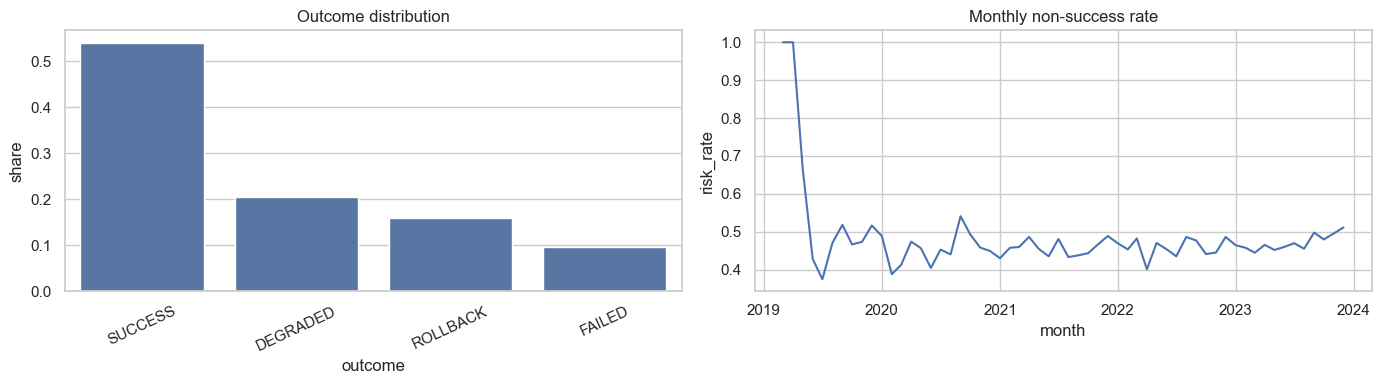

In [3]:
outcomes = data[OUTCOME_COLUMN].value_counts().rename_axis("outcome").to_frame("rows")
outcomes["share"] = outcomes["rows"] / len(data)
display(outcomes)

monthly = data.assign(
    month=data[DATE_COLUMN].dt.to_period("M").dt.to_timestamp(),
    deployment_risk=data[OUTCOME_COLUMN].ne("SUCCESS").astype(int),
).groupby("month", as_index=False).agg(rows=("deployment_id", "size"), risk_rate=("deployment_risk", "mean"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(data=outcomes.reset_index(), x="outcome", y="share", ax=axes[0])
axes[0].set_title("Outcome distribution")
axes[0].tick_params(axis="x", rotation=25)
sns.lineplot(data=monthly, x="month", y="risk_rate", ax=axes[1])
axes[1].set_title("Monthly non-success rate")
plt.tight_layout()

## Missingness and categorical coverage

In [4]:
missing = data[NUMERIC_COLUMNS].isna().sum().sort_values(ascending=False).to_frame("missing_rows")
missing["missing_share"] = missing["missing_rows"] / len(data)
display(missing.loc[missing["missing_rows"].gt(0)])

category_profile = pd.DataFrame({
    "unique_values": data[CATEGORICAL_COLUMNS].nunique(dropna=False),
    "missing_rows": data[CATEGORICAL_COLUMNS].isna().sum(),
    "most_common": [data[column].value_counts(dropna=False).index[0] for column in CATEGORICAL_COLUMNS],
})
display(category_profile)

,missing_rows,missing_share
uptime_days,711,0.03555
error_rate_predeploy,664,0.03320
network_stress_score,645,0.03225
firmware_release_age_days,636,0.03180


,unique_values,missing_rows,most_common
vendor_name,4,0,Siemens
device_type,6,0,PLC
hardware_series,48,0,Magelis-GTO
fleet_tier,3,0,TIER_2
site_criticality,3,0,MEDIUM
deployment_type,3,0,SCHEDULED


## Numeric relationships

These summaries are descriptive only. The production pipeline performs imputation and scaling after the chronological split.

,count,mean,std,min,25%,50%,75%,max
version_jump_magnitude,20000.0,1.714455,2.191600,0.100,0.100,0.600,2.600,10.600
network_stress_score,19355.0,0.301404,0.168971,0.001,0.170,0.278,0.410,1.000
error_rate_predeploy,19336.0,0.079239,0.080326,0.000,0.023,0.054,0.109,0.873
uptime_days,19289.0,535.976567,369.514928,5.000,190.000,525.000,855.000,1199.000
past_failure_count,20000.0,0.894150,1.196251,0.000,0.000,0.000,2.000,8.000
max_cvss_score,20000.0,3.977860,3.396974,0.000,0.000,4.300,6.900,10.000


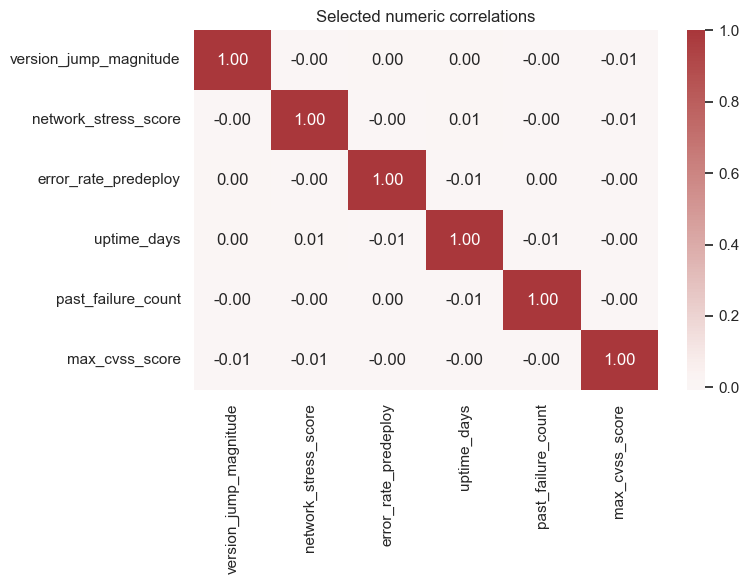

In [5]:
selected_numeric = [
    "version_jump_magnitude",
    "network_stress_score",
    "error_rate_predeploy",
    "uptime_days",
    "past_failure_count",
    "max_cvss_score",
]
display(data[selected_numeric].describe().T)

corr = data[selected_numeric].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, cmap="vlag", center=0, annot=True, fmt=".2f")
plt.title("Selected numeric correlations")
plt.tight_layout()

## Leakage boundary

- Identifiers (`deployment_id`, `device_id`, `site_id`, `firmware_fingerprint`) are never model features.
- `deployment_date` is only a split key.
- `time_to_failure_hours` and `rollback_required` are post-deployment leakage and are always removed.
- `deployment_outcome` creates the label and is never a predictor.

In [6]:
roles = pd.DataFrame({
    "columns": [ID_COLUMNS, [DATE_COLUMN], LEAKAGE_COLUMNS, [OUTCOME_COLUMN], CATEGORICAL_COLUMNS, NUMERIC_COLUMNS],
}, index=["identifiers", "split_only", "post_outcome_leakage", "target_source", "categorical_features", "numeric_features"])
display(roles)

,columns
identifiers,"[deployment_id, device_id, site_id, firmware_f..."
split_only,[deployment_date]
post_outcome_leakage,"[time_to_failure_hours, rollback_required]"
target_source,[deployment_outcome]
categorical_features,"[vendor_name, device_type, hardware_series, fl..."
numeric_features,"[version_jump_magnitude, kernel_touched, bootl..."
